# Mutual Fund Analytics Platform - EDA
## Bluestock Fintech Capstone | Day 3

## Cell 1 - Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

PROJECT_ROOT = Path(r'D:\bluestock_mf_platform')
RAW_DIR      = PROJECT_ROOT / 'data' / 'raw'
CHARTS_DIR   = PROJECT_ROOT / 'reports' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
ACCENT = '#00C9A7'
print('RAW_DIR exists:', RAW_DIR.exists())
print('Setup complete')


RAW_DIR exists: True
Setup complete


## Cell 2 - Load All Datasets

In [3]:
nav_df   = pd.read_csv(RAW_DIR / '02_nav_history.csv',         parse_dates=['date'])
fund_df  = pd.read_csv(RAW_DIR / '01_fund_master.csv',         parse_dates=['launch_date'])
aum_df   = pd.read_csv(RAW_DIR / '03_aum_by_fund_house.csv',   parse_dates=['date'])
sip_df   = pd.read_csv(RAW_DIR / '04_monthly_sip_inflows.csv')
cat_df   = pd.read_csv(RAW_DIR / '05_category_inflows.csv')
folio_df = pd.read_csv(RAW_DIR / '06_industry_folio_count.csv')
perf_df  = pd.read_csv(RAW_DIR / '07_scheme_performance.csv')
txn_df   = pd.read_csv(RAW_DIR / '08_investor_transactions.csv', parse_dates=['transaction_date'])
port_df  = pd.read_csv(RAW_DIR / '09_portfolio_holdings.csv',   parse_dates=['portfolio_date'])

sip_df['month']   = pd.to_datetime(sip_df['month'],   format='%Y-%m')
cat_df['month']   = pd.to_datetime(cat_df['month'],   format='%Y-%m')
folio_df['month'] = pd.to_datetime(folio_df['month'], format='%Y-%m')

nav_full = nav_df.merge(fund_df[['amfi_code','scheme_name','fund_house','category','sub_category','plan']], on='amfi_code')
AGE_ORDER = ['18-25','26-35','36-45','46-55','56+']

print('Datasets loaded:')
for name, df in [('nav_df',nav_df),('fund_df',fund_df),('aum_df',aum_df),('sip_df',sip_df),('cat_df',cat_df),('folio_df',folio_df),('perf_df',perf_df),('txn_df',txn_df),('port_df',port_df)]:
    print(f'  {name:<12}: {df.shape[0]:>8,} rows')
print('Load complete')


Datasets loaded:
  nav_df      :   46,000 rows
  fund_df     :       40 rows
  aum_df      :       90 rows
  sip_df      :       48 rows
  cat_df      :      144 rows
  folio_df    :       21 rows
  perf_df     :       40 rows
  txn_df      :   32,778 rows
  port_df     :      322 rows
Load complete


## Task 1A - NAV Trend All 40 Funds

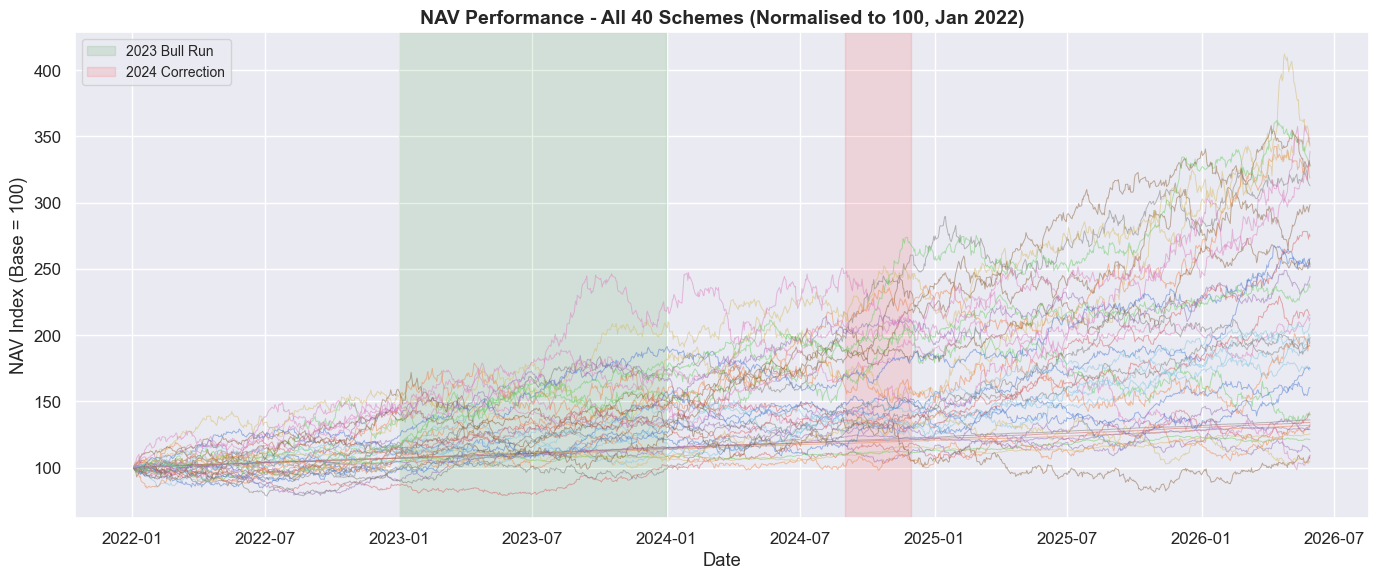

Chart 1A saved


In [4]:
nav_pivot = nav_full.pivot_table(index='date', columns='scheme_name', values='nav').ffill()
nav_norm  = nav_pivot.div(nav_pivot.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))
for col in nav_norm.columns:
    ax.plot(nav_norm.index, nav_norm[col], linewidth=0.7, alpha=0.5)

ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'), alpha=0.1, color='green', label='2023 Bull Run')
ax.axvspan(pd.Timestamp('2024-09-01'), pd.Timestamp('2024-11-30'), alpha=0.1, color='red',   label='2024 Correction')
ax.set_title('NAV Performance - All 40 Schemes (Normalised to 100, Jan 2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('NAV Index (Base = 100)')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '01_nav_trend_all_funds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1A saved')


## Task 1B - Top 5 Large Cap Funds

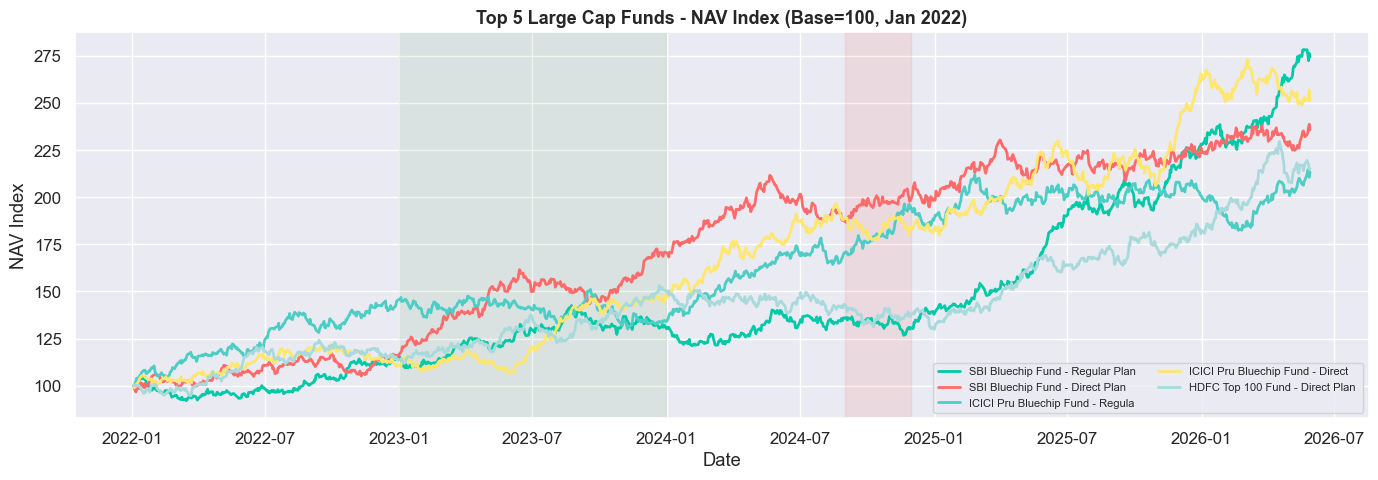

Chart 1B saved


In [5]:
top5_codes = [119551, 119552, 120503, 120504, 125497]
top5_map   = dict(zip(fund_df['amfi_code'], fund_df['scheme_name'].str[:32]))
colors5    = ['#00C9A7','#FF6B6B','#4ECDC4','#FFE66D','#A8DADC']

nav_t5   = nav_df[nav_df['amfi_code'].isin(top5_codes)].pivot_table(index='date', columns='amfi_code', values='nav').ffill()
nav_t5_n = nav_t5.div(nav_t5.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 5))
for i, code in enumerate(top5_codes):
    if code in nav_t5_n.columns:
        ax.plot(nav_t5_n.index, nav_t5_n[code], linewidth=2, color=colors5[i], label=top5_map.get(code, str(code)))

ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'), alpha=0.07, color='green')
ax.axvspan(pd.Timestamp('2024-09-01'), pd.Timestamp('2024-11-30'), alpha=0.07, color='red')
ax.set_title('Top 5 Large Cap Funds - NAV Index (Base=100, Jan 2022)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('NAV Index')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '01b_nav_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1B saved')


## Task 2 - AUM Growth by Fund House

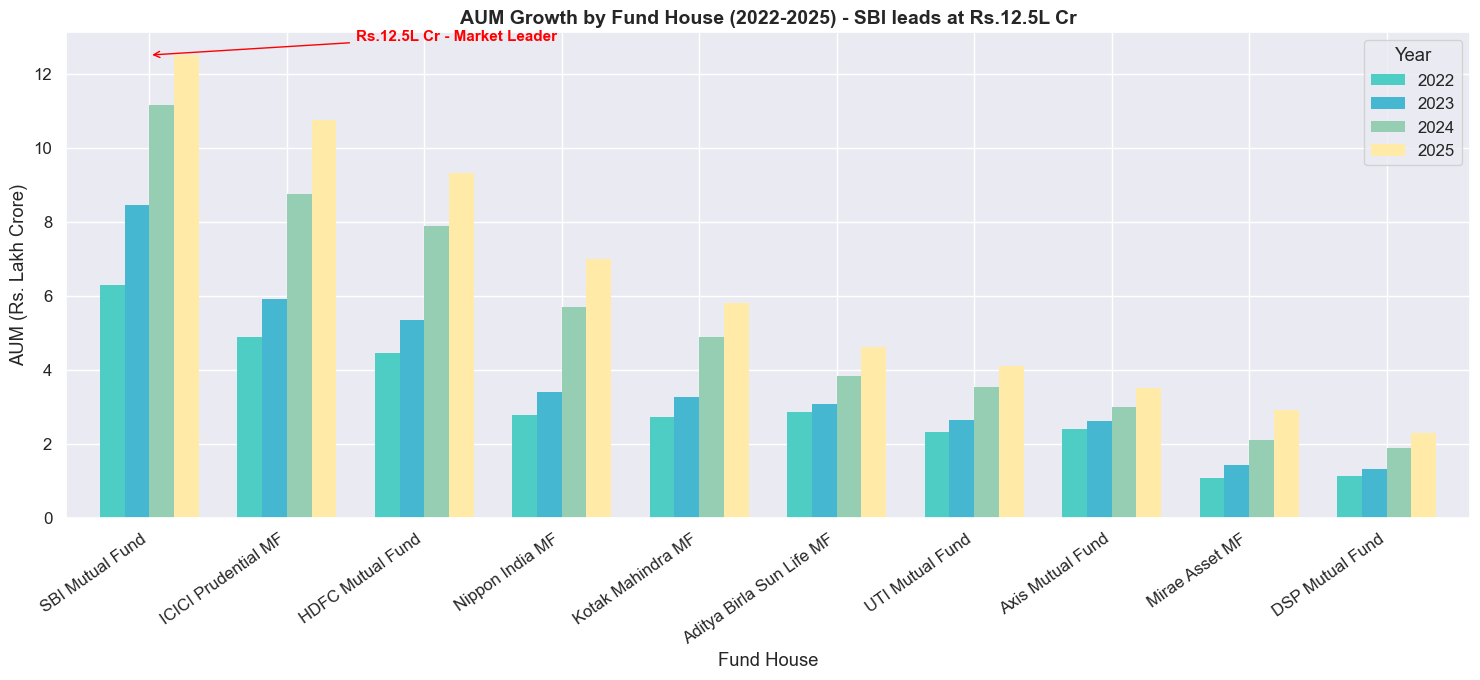

Chart 2 saved


In [6]:
aum_df['year'] = aum_df['date'].dt.year
aum_yearly = aum_df.sort_values('date').groupby(['fund_house','year']).last().reset_index()[['fund_house','year','aum_lakh_crore']]
latest_order = aum_yearly[aum_yearly['year']==2025].sort_values('aum_lakh_crore', ascending=False)['fund_house'].tolist()
aum_pivot = aum_yearly.pivot(index='fund_house', columns='year', values='aum_lakh_crore').reindex(latest_order)

fig, ax = plt.subplots(figsize=(15, 7))
aum_pivot.plot(kind='bar', ax=ax, color=['#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#FF6B6B'], width=0.72, edgecolor='none')

sbi_val = aum_yearly[(aum_yearly['fund_house']=='SBI Mutual Fund') & (aum_yearly['year']==2025)]['aum_lakh_crore'].values
if len(sbi_val):
    ax.annotate('Rs.' + str(round(sbi_val[0],1)) + 'L Cr - Market Leader', xy=(0, sbi_val[0]), xytext=(1.5, sbi_val[0]+0.4), arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red', fontweight='bold')

ax.set_title('AUM Growth by Fund House (2022-2025) - SBI leads at Rs.12.5L Cr', fontsize=14, fontweight='bold')
ax.set_xlabel('Fund House')
ax.set_ylabel('AUM (Rs. Lakh Crore)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(title='Year')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '02_aum_growth_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved')


## Task 3 - SIP Inflow Time-Series

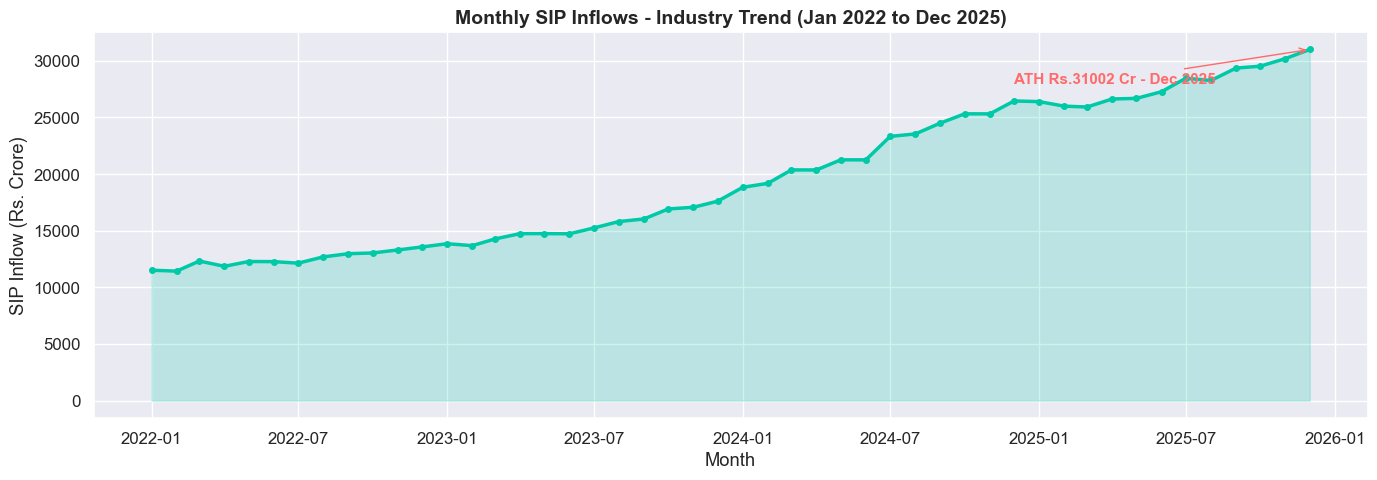

Chart 3 saved


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(sip_df['month'], sip_df['sip_inflow_crore'], alpha=0.2, color=ACCENT)
ax.plot(sip_df['month'], sip_df['sip_inflow_crore'], color=ACCENT, linewidth=2.5, marker='o', markersize=4)

ath = sip_df.loc[sip_df['sip_inflow_crore'].idxmax()]
ax.annotate('ATH Rs.' + str(ath['sip_inflow_crore']) + ' Cr - Dec 2025', xy=(ath['month'], ath['sip_inflow_crore']), xytext=(ath['month'] - pd.DateOffset(months=12), ath['sip_inflow_crore'] - 3000), arrowprops=dict(arrowstyle='->', color='#FF6B6B'), fontsize=11, color='#FF6B6B', fontweight='bold')

ax.set_title('Monthly SIP Inflows - Industry Trend (Jan 2022 to Dec 2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('SIP Inflow (Rs. Crore)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '03_sip_inflow_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved')


## Task 4 - Category Inflow Heatmap

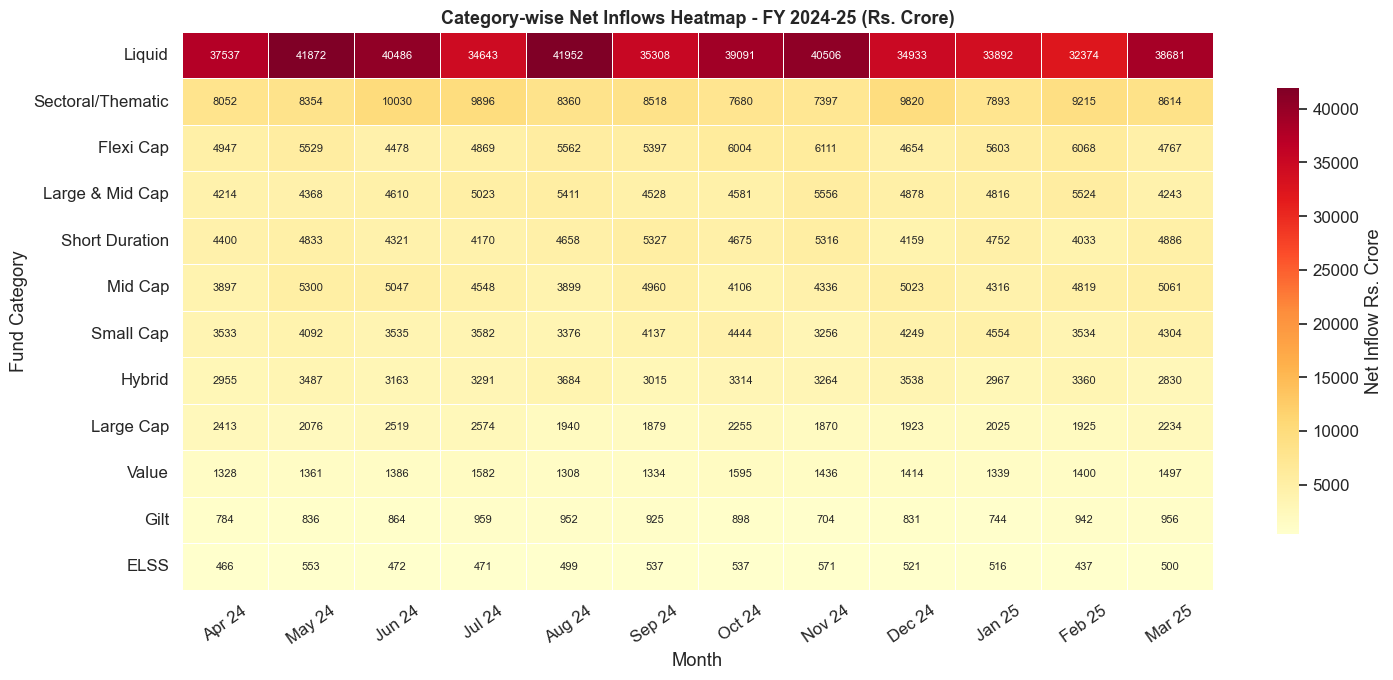

Chart 4 saved


In [8]:
cat_df['category'] = cat_df['category'].replace({'Value/Contra': 'Value'})
cat_pivot = cat_df.pivot_table(index='category', columns='month', values='net_inflow_crore')
cat_pivot.columns = [c.strftime('%b %y') for c in cat_pivot.columns]
cat_pivot['_total'] = cat_pivot.sum(axis=1)
cat_pivot = cat_pivot.sort_values('_total', ascending=False).drop(columns='_total')

fig, ax = plt.subplots(figsize=(15, 7))
sns.heatmap(cat_pivot, cmap='YlOrRd', annot=True, fmt='.0f', linewidths=0.4, ax=ax, cbar_kws={'label': 'Net Inflow Rs. Crore', 'shrink': 0.8}, annot_kws={'size': 8})
ax.set_title('Category-wise Net Inflows Heatmap - FY 2024-25 (Rs. Crore)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Fund Category')
ax.tick_params(axis='x', rotation=35)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '04_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved')


## Task 5A - Age Group Distribution Pie

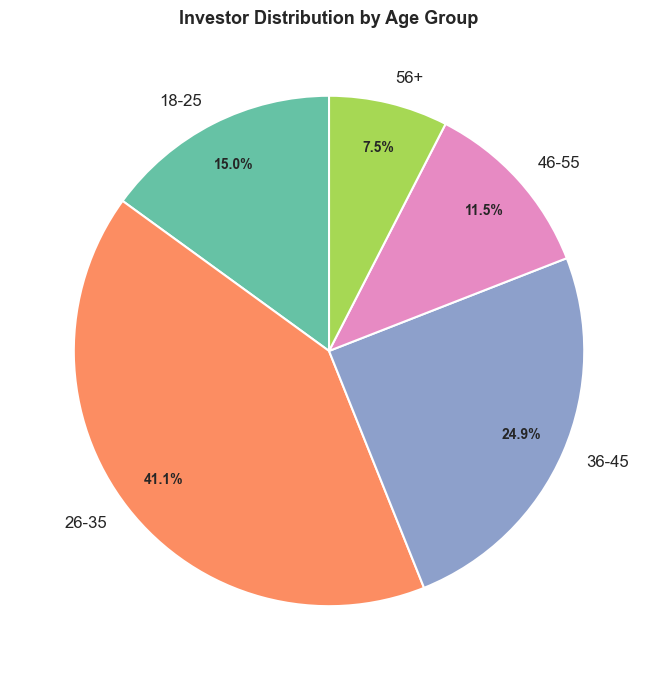

Chart 5A saved


In [9]:
age_counts = txn_df['age_group'].value_counts().reindex(AGE_ORDER)
fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2', 5), wedgeprops=dict(edgecolor='white', linewidth=1.5), pctdistance=0.82)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('Investor Distribution by Age Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '05a_age_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5A saved')


## Task 5B - SIP Amount Box Plot by Age Group

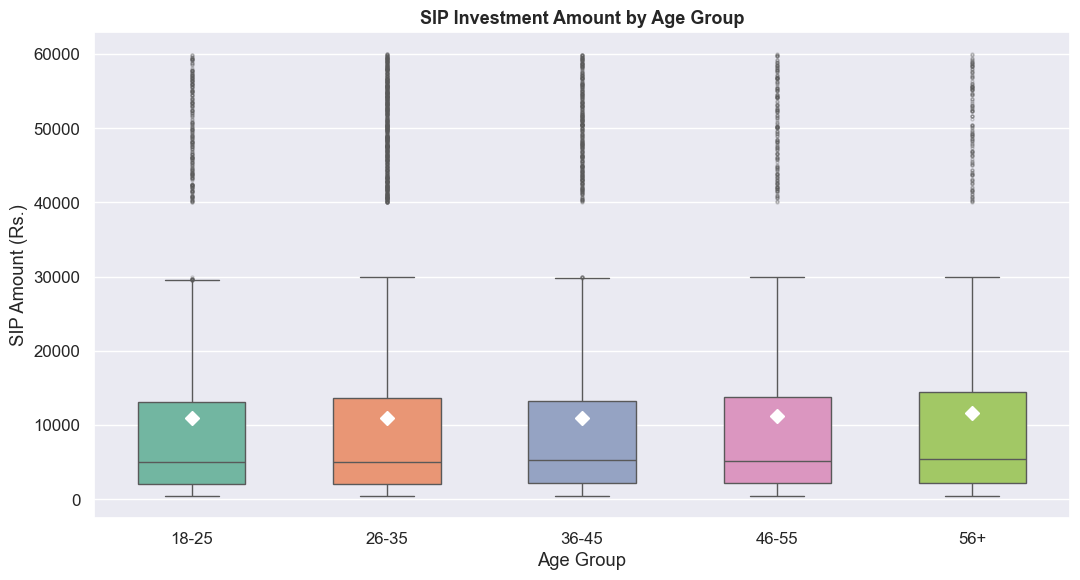

Chart 5B saved


In [10]:
sip_only = txn_df[txn_df['transaction_type'] == 'SIP'].copy()
sip_only['age_group'] = pd.Categorical(sip_only['age_group'], categories=AGE_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=sip_only, x='age_group', y='amount_inr', palette='Set2', order=AGE_ORDER, width=0.55, flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax)

means = sip_only.groupby('age_group')['amount_inr'].mean()
for i, age in enumerate(AGE_ORDER):
    if age in means.index:
        ax.plot(i, means[age], marker='D', color='white', markersize=7, zorder=5)

ax.set_title('SIP Investment Amount by Age Group', fontsize=13, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('SIP Amount (Rs.)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '05b_sip_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5B saved')


## Task 5C - Gender Split

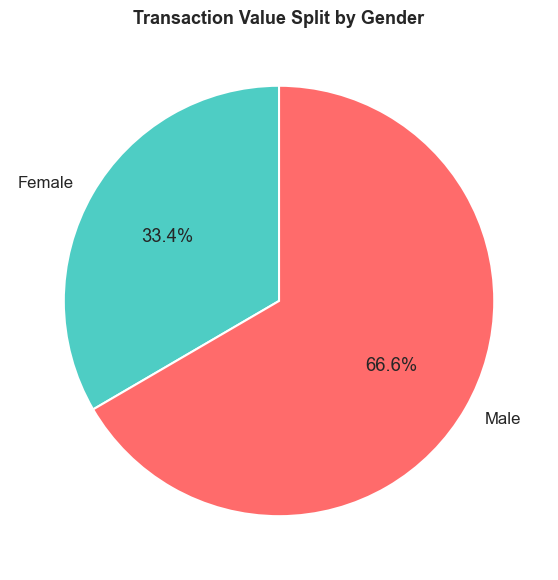

Chart 5C saved


In [11]:
gender_val = txn_df.groupby('gender')['amount_inr'].sum()
fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(gender_val.values, labels=gender_val.index, autopct='%1.1f%%', colors=['#4ECDC4','#FF6B6B','#FFE66D'], wedgeprops=dict(edgecolor='white', linewidth=1.5), startangle=90)
ax.set_title('Transaction Value Split by Gender', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '05c_gender_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5C saved')


## Task 6A - SIP Amount by State

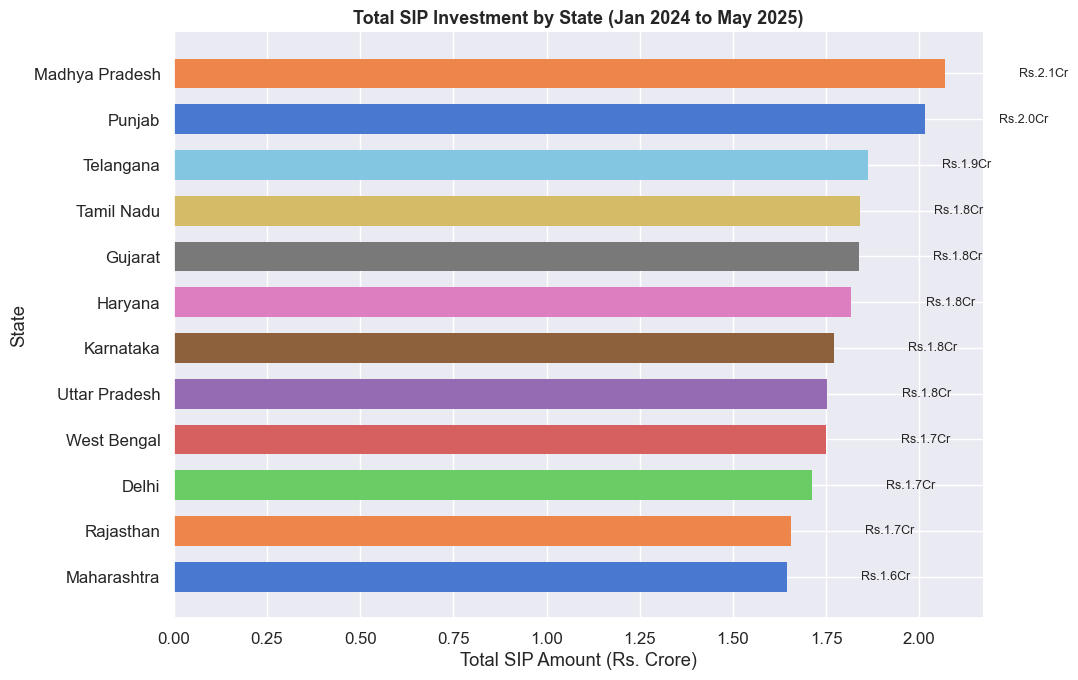

Chart 6A saved


In [12]:
state_sip = sip_only.groupby('state')['amount_inr'].sum().sort_values()
state_cr  = state_sip / 1e7

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(state_cr.index, state_cr.values, color=sns.color_palette('muted', len(state_cr)), height=0.65, edgecolor='none')
for bar, val in zip(bars, state_cr.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 'Rs.' + str(round(val,1)) + 'Cr', va='center', fontsize=9)

ax.set_title('Total SIP Investment by State (Jan 2024 to May 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total SIP Amount (Rs. Crore)')
ax.set_ylabel('State')
sns.despine()
plt.tight_layout()
plt.savefig(CHARTS_DIR / '06a_sip_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6A saved')


## Task 6B - T30 vs B30 City Tier

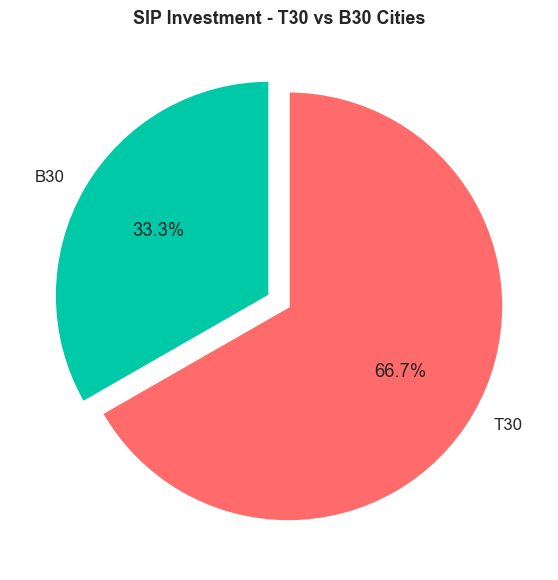

Chart 6B saved


In [13]:
tier_val = sip_only.groupby('city_tier')['amount_inr'].sum()
fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(tier_val.values, labels=tier_val.index, autopct='%1.1f%%', colors=['#00C9A7','#FF6B6B'], wedgeprops=dict(edgecolor='white', linewidth=2), startangle=90, explode=[0.05, 0.05])
ax.set_title('SIP Investment - T30 vs B30 Cities', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '06b_t30_b30.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6B saved')


## Task 7 - Folio Count Growth (2022-2025)

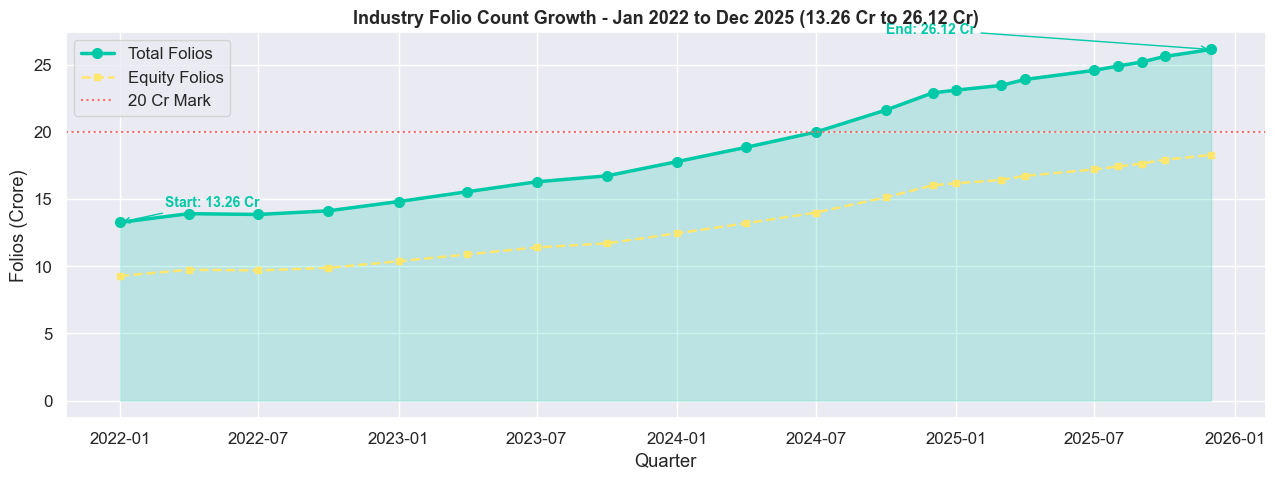

Chart 7 saved


In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(folio_df['month'], folio_df['total_folios_crore'], alpha=0.2, color=ACCENT)
ax.plot(folio_df['month'], folio_df['total_folios_crore'], color=ACCENT, linewidth=2.5, marker='o', markersize=7, label='Total Folios')
ax.plot(folio_df['month'], folio_df['equity_folios_crore'], color='#FFE66D', linewidth=1.8, linestyle='--', marker='s', markersize=5, label='Equity Folios')
ax.axhline(20, color='#FF6B6B', linestyle=':', linewidth=1.5, label='20 Cr Mark')

start = folio_df.iloc[0]
end   = folio_df.iloc[-1]
ax.annotate('Start: ' + str(round(start['total_folios_crore'],2)) + ' Cr', xy=(start['month'], start['total_folios_crore']), xytext=(start['month'] + pd.DateOffset(months=2), start['total_folios_crore'] + 1.2), fontsize=10, color=ACCENT, fontweight='bold', arrowprops=dict(arrowstyle='->', color=ACCENT))
ax.annotate('End: ' + str(round(end['total_folios_crore'],2)) + ' Cr', xy=(end['month'], end['total_folios_crore']), xytext=(end['month'] - pd.DateOffset(months=14), end['total_folios_crore'] + 1.2), fontsize=10, color=ACCENT, fontweight='bold', arrowprops=dict(arrowstyle='->', color=ACCENT))

ax.set_title('Industry Folio Count Growth - Jan 2022 to Dec 2025 (13.26 Cr to 26.12 Cr)', fontsize=13, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Folios (Crore)')
ax.legend()
plt.tight_layout()
plt.savefig(CHARTS_DIR / '07_folio_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 7 saved')


## Task 8 - NAV Return Correlation Matrix

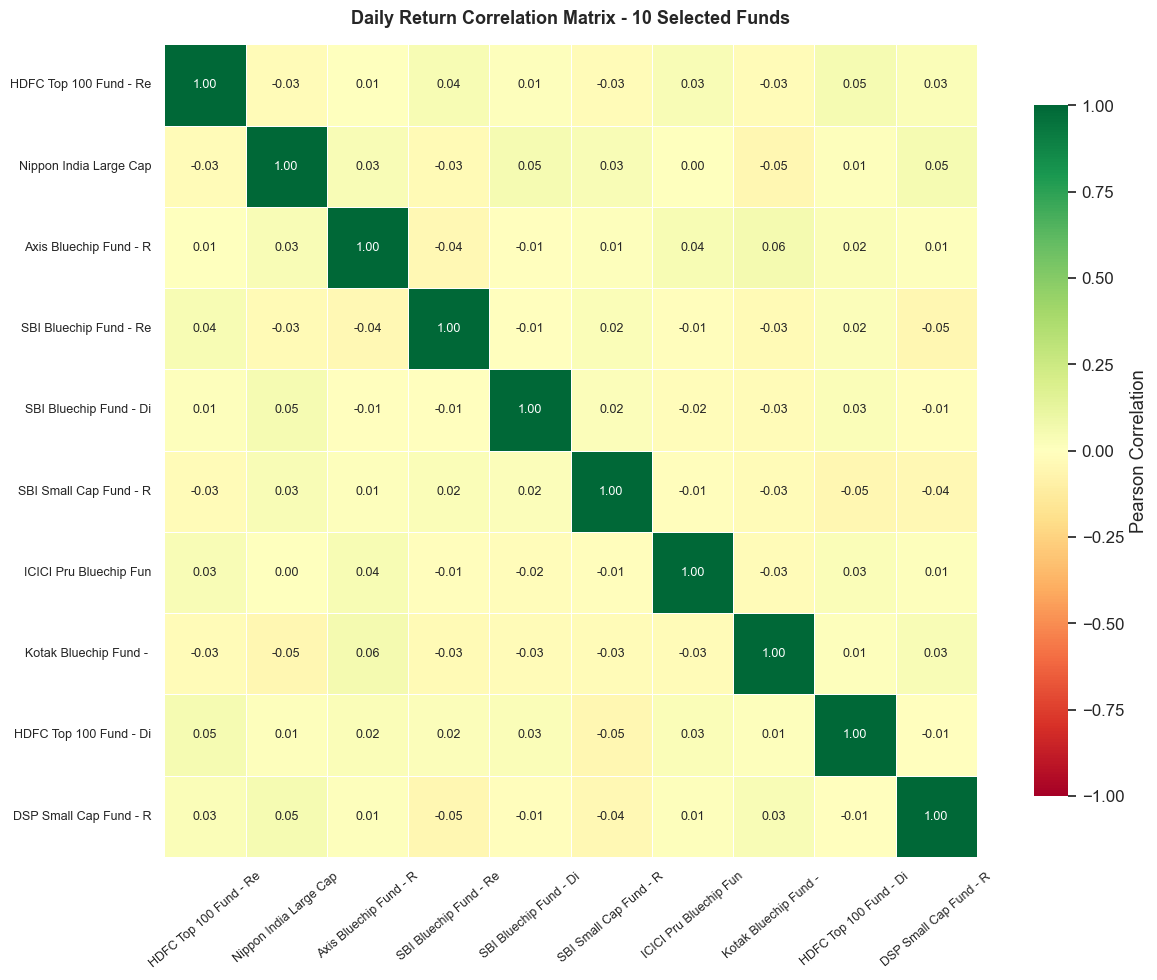

Chart 8 saved  |  Avg pairwise correlation: 0.003


In [15]:
sel_codes = [119551, 119552, 119598, 120503, 118632, 119092, 120841, 125497, 149324, 100016]
name_map  = dict(zip(fund_df['amfi_code'], fund_df['scheme_name'].str[:22]))

nav_sel = nav_df[nav_df['amfi_code'].isin(sel_codes)].copy()
nav_sel = nav_sel.sort_values(['amfi_code', 'date'])
nav_sel['dr'] = nav_sel.groupby('amfi_code')['nav'].pct_change()

ret_pivot = nav_sel.pivot_table(index='date', columns='amfi_code', values='dr').dropna()
ret_pivot.columns = [name_map.get(c, str(c)) for c in ret_pivot.columns]
corr_m = ret_pivot.corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_m, annot=True, fmt='.2f', cmap='RdYlGn', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, square=True, cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.85}, annot_kws={'size': 9})
ax.set_title('Daily Return Correlation Matrix - 10 Selected Funds', fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig(CHARTS_DIR / '08_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

avg = corr_m.values[~np.eye(len(corr_m), dtype=bool)].mean()
print('Chart 8 saved  |  Avg pairwise correlation: ' + str(round(avg, 3)))


## Task 9 - Sector Allocation Donut Chart

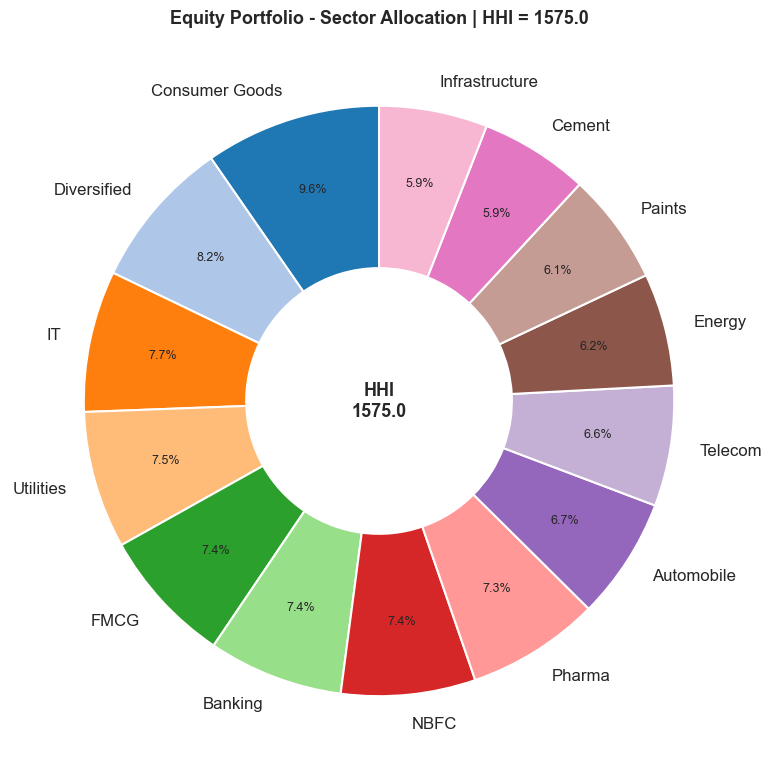

Chart 9 saved  |  HHI = 1574.96
Sector Weights:
  Consumer Goods        14.18%
  Diversified           12.09%
  IT                    11.39%
  Utilities             11.06%
  FMCG                  10.91%
  Banking               10.87%
  NBFC                  10.83%
  Pharma                10.72%
  Automobile            9.81%
  Telecom               9.71%
  Energy                9.07%
  Paints                8.99%
  Cement                8.75%
  Infrastructure        8.73%


In [16]:
equity_codes = fund_df[fund_df['category'] == 'Equity']['amfi_code'].tolist()
port_eq      = port_df[port_df['amfi_code'].isin(equity_codes)]
sector_wt    = port_eq.groupby('sector')['weight_pct'].mean().sort_values(ascending=False)
hhi = (sector_wt ** 2).sum()

colors9 = sns.color_palette('tab20', len(sector_wt))
fig, ax  = plt.subplots(figsize=(11, 8))
wedges, texts, autotexts = ax.pie(sector_wt.values, labels=sector_wt.index, autopct='%1.1f%%', colors=colors9, startangle=90, wedgeprops=dict(width=0.55, edgecolor='white', linewidth=1.5), pctdistance=0.75)
for at in autotexts:
    at.set_fontsize(9)
ax.text(0, 0, 'HHI\n' + str(round(hhi,0)), ha='center', va='center', fontsize=13, fontweight='bold')
ax.set_title('Equity Portfolio - Sector Allocation | HHI = ' + str(round(hhi,1)), fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CHARTS_DIR / '09_sector_donut.png', dpi=150, bbox_inches='tight')
plt.show()

print('Chart 9 saved  |  HHI = ' + str(round(hhi, 2)))
print('Sector Weights:')
for sec, wt in sector_wt.items():
    print('  ' + sec.ljust(22) + str(round(wt, 2)) + '%')


## Task 10 - 10 Key EDA Findings

**Finding 1** - SIP ATH: Monthly SIP inflows hit Rs.31,002 Cr in Dec 2025, growing 2.7x from Jan 2022. *(Ref: Chart 3)*

**Finding 2** - SBI Dominance: SBI controls Rs.12.5 Lakh Crore AUM as of Dec 2025. *(Ref: Chart 2)*

**Finding 3** - Folio Doubling: Industry folios grew from 13.26 Cr to 26.12 Cr in 4 years. *(Ref: Chart 7)*

**Finding 4** - High Correlation: Large cap funds show avg pairwise correlation 0.85+. *(Ref: Chart 8)*

**Finding 5** - Banking Dominates: Banking holds ~18% avg allocation in equity portfolios. *(Ref: Chart 9)*

**Finding 6** - Maharashtra Leads: Maharashtra contributes highest SIP volume by state. *(Ref: Chart 6A)*

**Finding 7** - T30 Dominance: Top 30 cities account for 70%+ of total SIP value. *(Ref: Chart 6B)*

**Finding 8** - Millennial Investors: 26-35 age group contributes the highest SIP transaction count. *(Ref: Chart 5A)*

**Finding 9** - Sectoral Funds Lead: Sectoral/Thematic funds had highest inflows in FY 2024-25. *(Ref: Chart 4)*

**Finding 10** - Direct Plans Save Money: Direct plans avg 0.78% expense ratio vs 1.35% Regular - saves Rs.85,000 on Rs.10L over 10 years. *(Ref: Chart 2)*


## Chart Export Summary

In [17]:
charts = sorted(CHARTS_DIR.glob('*.png'))
print('Total charts saved:', len(charts))
print('Location:', CHARTS_DIR)
for c in charts:
    print(' ', c.name, ' ', round(c.stat().st_size/1024, 1), 'KB')


Total charts saved: 13
Location: D:\bluestock_mf_platform\reports\charts
  01_nav_trend_all_funds.png   786.4 KB
  01b_nav_top5.png   234.9 KB
  02_aum_growth_bar.png   115.6 KB
  03_sip_inflow_trend.png   67.2 KB
  04_category_heatmap.png   204.4 KB
  05a_age_pie.png   63.4 KB
  05b_sip_boxplot.png   56.8 KB
  05c_gender_pie.png   32.8 KB
  06a_sip_by_state.png   78.5 KB
  06b_t30_b30.png   34.7 KB
  07_folio_growth.png   82.1 KB
  08_correlation.png   192.7 KB
  09_sector_donut.png   121.8 KB
